In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

Transaction cleaning
    1- Delete the single transaction during the day.
    2- save the first attend and last leave for each day
    3- delete all the transaction between first and last one for each day

In [3]:
#Load Preprared data

get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3339_alwadi'))
csv_file = '3339_alwadi_Prepared_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)
Dset = pd.read_csv(absolute_path)

# Ensure 'TransDateTime' is a datetime type
Dset['TransDateTime'] = pd.to_datetime(Dset['TransDateTime'])

# Sort the data
Dset.sort_values(by=['EmployeeId', 'TransDateTime'], inplace=True)

single_transactions = pd.DataFrame()

# Function to filter the first "Attend" and the last "Leave"
def filter_transactions(group):
    if len(group) == 1:
        global single_transactions
        single_transactions = pd.concat([single_transactions,group])
        return None  # Remove if there's only one transaction in a day
    first_attend = group[group['Type'] == 'Attend'].head(1)
    last_leave = group[group['Type'] == 'Leave'].tail(1)
    return pd.concat([first_attend, last_leave])

# Apply the function to each group
cleaned_data = Dset.groupby(['EmployeeId', Dset['TransDateTime'].dt.date]).apply(filter_transactions).reset_index(drop=True)

# Drop any possible NaN entries if there are days with only one type of transaction
cleaned_data.dropna(subset=['TransDateTime'], inplace=True)

# Save single transactions to a separate CSV file
output_dir = '../../data/processed/3339_alwadi'
os.makedirs(output_dir, exist_ok=True)
single_transactions.to_csv(os.path.join(output_dir, '3339_alwadi_Single_Transaction_data.csv'), index=False)


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_5288\1444381461.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cleaned_data = Dset.groupby(['EmployeeId', Dset['TransDateTime'].dt.date]).apply(filter_transactions).reset_index(drop=True)


Data aggregation:
  1- create new view for the data
  2- reducing the size of the data lmost %50
Data Manipulation
  1- extract the hours of the attendance
  2- extract the minuts of the attendance
  3- drop the column Type

In [4]:
# CheckInTime  is the time attend 
# CheckOutTIme is the time of Leave
cleaned_data['CheckInTime'] = cleaned_data.apply(lambda x: x['Transtime'] if x['Type'] == 'Attend' else None, axis=1)
cleaned_data['CheckOutTime'] = cleaned_data.apply(lambda x: x['Transtime'] if x['Type'] == 'Leave' else None, axis=1)

# Aggregate to ensure each day has one row per employee
pivoted_Dset = cleaned_data.groupby(['EmployeeId', 'Transdate']).agg({
    'CheckInTime': 'first',
    'CheckOutTime': 'last'
}).reset_index()

# Calculate durations for the rows with both checkInTime and CheckOutTime
pivoted_Dset['CheckInDateTime'] = pd.to_datetime(pivoted_Dset['Transdate'].astype(str) + ' ' + pivoted_Dset['CheckInTime'].astype(str), errors='coerce')
pivoted_Dset['CheckOutDateTime'] = pd.to_datetime(pivoted_Dset['Transdate'].astype(str) + ' ' + pivoted_Dset['CheckOutTime'].astype(str), errors='coerce')

# Filter rows where either time is null
pivoted_Dset.dropna(subset=['CheckInDateTime', 'CheckOutDateTime'], inplace=True)

# Claculate the hours and seconds 
pivoted_Dset['hours'] = (pivoted_Dset['CheckOutDateTime'] - pivoted_Dset['CheckInDateTime']).dt.total_seconds() / 3600
#pivoted_Dset['seconds'] = (pivoted_Dset['CheckOutDateTime'] - pivoted_Dset['CheckInDateTime']).dt.total_seconds()

pivoted_Dset['DayOfWeek'] = cleaned_data['TransDateTime'].dt.dayofweek  # Monday=0, Sunday=6

# The new output format
final_Dset = pivoted_Dset[['EmployeeId', 'Transdate','DayOfWeek', 'CheckInTime', 'CheckOutTime', 'hours']]

# Convert 'hours' to numeric if not already to ensure all operations work smoothly
final_Dset['hours'] = pd.to_numeric(final_Dset['hours'], errors='coerce')

# Remove rows where 'hours' are less than 0.5 or are negative
final_Dset = final_Dset[(final_Dset['hours'] >= 0.5) & (final_Dset['hours'] > 0)]

# Optionally, drop rows with NaN values in the 'hours' column
final_Dset = final_Dset.dropna(subset=['hours'])

final_Dset.drop_duplicates()

print(final_Dset)
# Save the data to CSV file 
output_dir = '../../data/processed/3339_alwadi'
os.makedirs(output_dir, exist_ok=True)
final_Dset.to_csv(os.path.join(output_dir, '3339_alwadi_transformation_data.csv'), index=False)


      EmployeeId   Transdate  DayOfWeek CheckInTime CheckOutTime      hours
0          51835  2024-05-08          2    10:21:00     17:01:00   6.666667
1          51835  2024-05-09          2    18:09:00     20:37:00   2.466667
2          51835  2024-05-12          3    09:08:00     09:43:00   0.583333
4          51835  2024-07-01          6    08:03:00     11:59:00   3.933333
5          51835  2024-07-02          6    07:58:00     22:05:00  14.116667
...          ...         ...        ...         ...          ...        ...
9300       52952  2024-07-29          5    09:55:00     15:55:00   6.000000
9301       52952  2024-07-30          5    10:00:00     15:55:00   5.916667
9302       52952  2024-07-31          6    10:01:00     15:55:00   5.900000
9303       52952  2024-08-01          6    09:57:00     15:56:00   5.983333
9304       52952  2024-08-02          0    12:55:00     15:56:00   3.016667

[7574 rows x 6 columns]


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_5288\3609657657.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_Dset['hours'] = pd.to_numeric(final_Dset['hours'], errors='coerce')


Data Profile

In [5]:
from pandas_profiling import ProfileReport

# Load your data
# final_Dset = pd.read_csv('path_to_your_file.csv')  # Assuming the DataFrame is named final_Dset

# Generate the data profile report
profile = ProfileReport(final_Dset, title="Attendance Data Profile", explorative=True)

# Display the report in the notebook
profile.to_notebook_iframe()

# Alternatively, you can save the report to a file
profile.to_file("attendance_data_profile.html")

C:\Users\fzmaj\AppData\Local\Temp\ipykernel_5288\907384416.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Data visualization

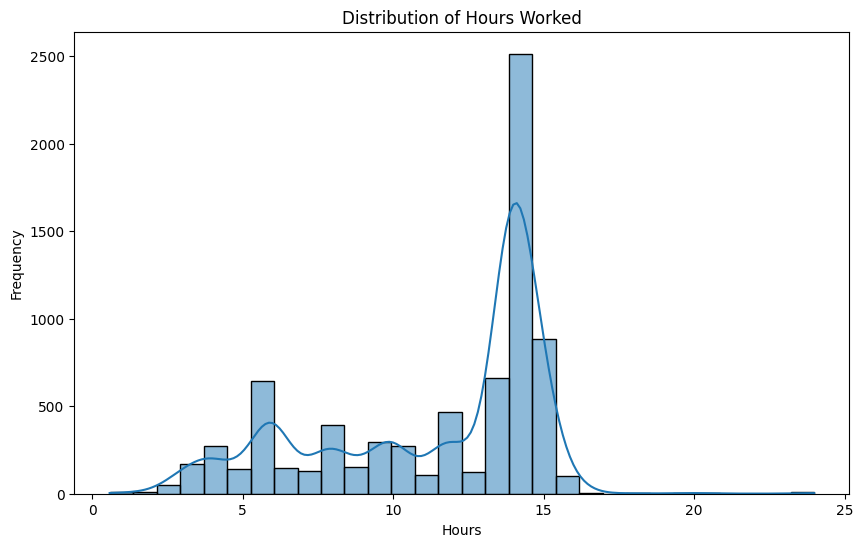

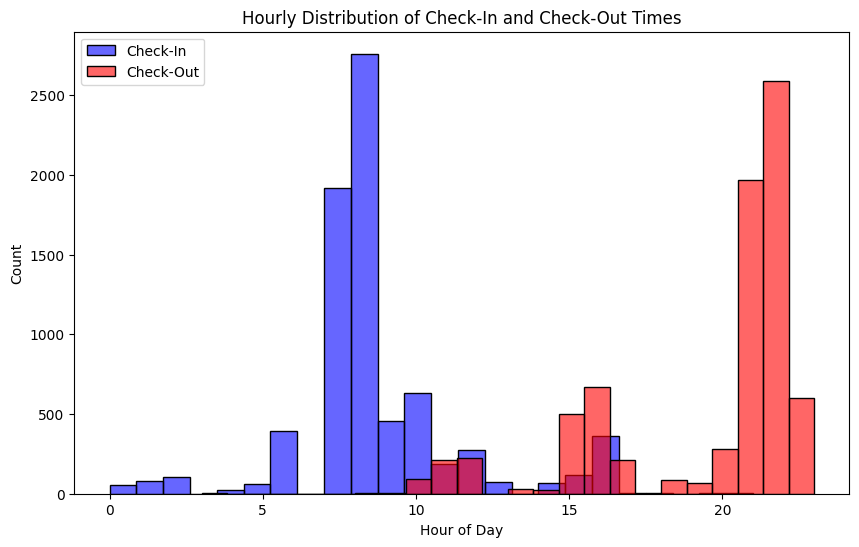

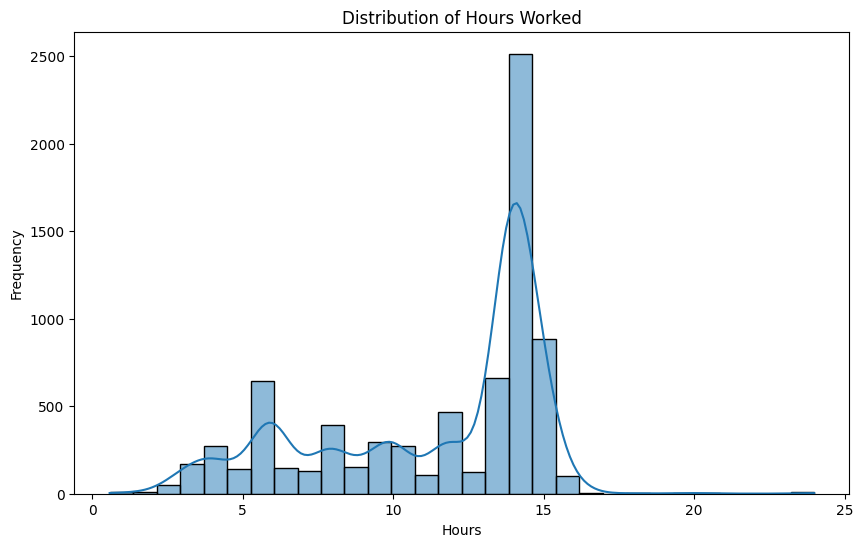

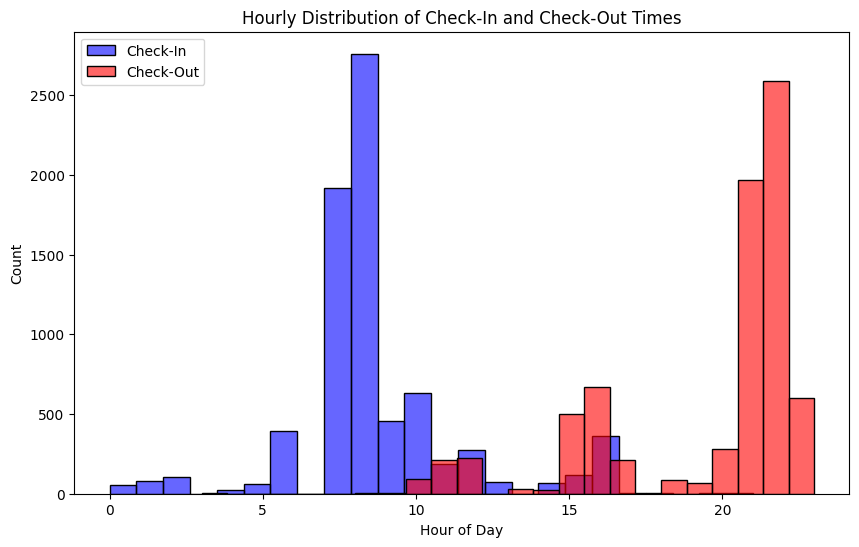

In [7]:
%matplotlib inline
# Distribution of hours worked
plt.figure(figsize=(10, 6))
sns.histplot(final_Dset['hours'], bins=30, kde=True)
plt.title('Distribution of Hours Worked')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

# Distribution of Check-In and Check-Out times
plt.figure(figsize=(10, 6))
sns.histplot(final_Dset['CheckInTime'].astype(str).str[:2].astype(int), bins=24, color='blue', alpha=0.6, label='Check-In')
sns.histplot(final_Dset['CheckOutTime'].astype(str).str[:2].astype(int), bins=24, color='red', alpha=0.6, label='Check-Out')
plt.title('Hourly Distribution of Check-In and Check-Out Times')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.legend()
plt.show()